In [2]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
data_path = "/media/apollo/projects/hc-18/data/"

os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper
import bootstrapped_estimation as bootstrap



scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf

sessions = ['Achilles_10252013','Buddy_06272013','Cicero_09012014','Gatsby_08022013','Achilles_11012013','Cicero_09102014','Cicero_09172014','Gatsby_08282013']

rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [3]:

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [2]:

output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['state'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['shanks_distance'] = []
output_dict['slope'] = []
output_dict['intercept'] = []
output_dict['r_value'] = []
output_dict['p_value'] = []
output_dict['std_err'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

states = ['pre','post']
for session in sessions:

    print(session)
    logging.info('session = ' + str(session))
    
    all_shanks,left_shanks,right_shanks = hc11_bf.get_shanks_info(session)
    LFP,srate,SWS,SWS_lfp_index,SWS_lfp_index_pre,SWS_lfp_index_pos = hc11_bf.load_lfp_hc11_data(session)
    # spike_times,spike_ids,pyr_ids,int_ids = hc11_bf.load_spikes_hc11_data(RatName)
        
    os.chdir(scripts_path)
    all_shanks_electrode_position = np.load(f'electrode_position_{session}.npy')

    all_shanks_distance_to_ref = np.arange(0,(len(all_shanks)/2)*200,200)
    all_shanks_distance_to_ref = np.concatenate([all_shanks_distance_to_ref,all_shanks_distance_to_ref])
    accepted_shanks = np.setdiff1d(np.arange(len(all_shanks)),rejected_shanks[session])

    for state in states:
        if state == 'pre':
            # lfp_index = SWS_lfp_index_pre[-int(30*60*srate):]
            lfp_index = SWS_lfp_index_pre[0:int(30*60*srate)]
        elif state == 'post':
            lfp_index = SWS_lfp_index_pos[0:int(30*60*srate)]
                
        # for shank_1_idx in [0]:
        for shank_1_idx in np.arange(0,len(accepted_shanks)-1):    
            
            shank_1 = accepted_shanks[shank_1_idx]
            # print('Shank 1 = ' + str(shank_1))
    
    
            Imaxripple = np.where(all_shanks_electrode_position[shank_1]==0)[0][0]
            shanks = all_shanks[shank_1]
            ripple_lfp_1 = LFP[shanks[Imaxripple],lfp_index].copy()
    
            ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,100,250))
            ripple_hilbert_1 = hc11_bf.hilbert(ripple_filtered_1)
            # ripple_phase_1 = np.angle(ripple_hilbert_1)
            ripple_amp_1 = np.abs(ripple_hilbert_1)
    
            # for shank_2_idx in [1,9]:
            for shank_2_idx in np.arange(shank_1_idx+1,len(accepted_shanks)):
                shank_2 = accepted_shanks[shank_2_idx]
                # print('Shank 2 = ' + str(shank_2))
    
                shanks_distance = np.abs((all_shanks_distance_to_ref[shank_1] - all_shanks_distance_to_ref[shank_2]))
                if shanks_distance > 1200:
                    continue

                Imaxripple = np.where(all_shanks_electrode_position[shank_2]==0)[0][0]
                shanks = all_shanks[shank_2]
                ripple_lfp_2 = LFP[shanks[Imaxripple],lfp_index].copy()
    
                ripple_filtered_2 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_2,srate,100,250))
                ripple_hilbert_2 = hc11_bf.hilbert(ripple_filtered_2)
                # ripple_phase_2 = np.angle(ripple_hilbert_2)
                ripple_amp_2 = np.abs(ripple_hilbert_2)
    
        
                # amp_window_length = 0.1*srate
                # non_overlap = 0.05*srate
                amp_window_length = 0.05*srate
                non_overlap = 0.01*srate
                overlap = amp_window_length-non_overlap
                binned_amplitude_1 = []
                binned_amplitude_2 = []
        
                for ll in np.arange(0,((lfp_index.shape[0]-amp_window_length)/non_overlap)):
                    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)
        
                    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
                    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
        
                binned_amplitude_1 = np.array(binned_amplitude_1)
                binned_amplitude_2 = np.array(binned_amplitude_2)
        
                slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)


            
                if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                    side = 'ipsi'
                else:
                    side = 'contra'
    
    
                output_dict['rat'].append(session[0:3])
                output_dict['session'].append(session)
                output_dict['side'].append(side)
                output_dict['state'].append(state)
                output_dict['shank_1'].append(shank_1)
                output_dict['shank_2'].append(shank_2)
                output_dict['shanks_distance'].append(shanks_distance)            
                output_dict['slope'].append(slope)
                output_dict['intercept'].append(intercept)
                output_dict['r_value'].append(r_value)
                output_dict['p_value'].append(p_value)
                output_dict['std_err'].append(std_err)

df = pd.DataFrame(output_dict)
df
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_AmpAmpCoupling_WholeSignal_PrePost.csv',index=False)


Achilles_10252013
Buddy_06272013
Cicero_09012014
Gatsby_08022013
Achilles_11012013
Cicero_09102014
Cicero_09172014
Gatsby_08282013


,rat,session,side,state,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.856126,3.040880,0.983945,0.0,0.000366
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.824979,4.194897,0.971639,0.0,0.000473
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.796551,7.845323,0.958331,0.0,0.000560
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.714414,10.774275,0.946081,0.0,0.000577
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.685440,12.846040,0.932308,0.0,0.000627
...,...,...,...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,1.377306,-9.893647,0.954591,0.0,0.001013
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.720612,8.447304,0.899948,0.0,0.000823
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,1.218413,-6.740792,0.967035,0.0,0.000756
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.634193,10.255005,0.906980,0.0,0.000694


In [5]:
path = "/home/apollo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

filename = 'Figure_Ripple_AmpAmpCoupling_WholeSignal_PrePost.csv'
df = pd.read_csv(filename)

# Set reference categories
# df['side'] = pd.Categorical(df['side'], categories=['ipsi', 'contra'], ordered=True)
# df['state'] = pd.Categorical(df['state'], categories=['pre', 'post'], ordered=True)
df


,rat,session,side,state,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.856126,3.040880,0.983945,0.0,0.000366
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.824979,4.194897,0.971639,0.0,0.000473
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.796551,7.845323,0.958331,0.0,0.000560
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.714414,10.774275,0.946081,0.0,0.000577
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.685440,12.846040,0.932308,0.0,0.000627
...,...,...,...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,1.377306,-9.893647,0.954591,0.0,0.001013
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.720612,8.447304,0.899948,0.0,0.000823
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,1.218413,-6.740792,0.967035,0.0,0.000756
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.634193,10.255005,0.906980,0.0,0.000694


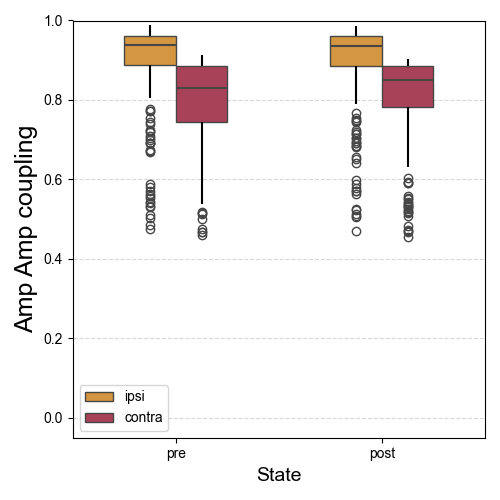

In [6]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#               hue_order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="state",order = ['pre','post'], y="r_value", hue='side',
            hue_order=['ipsi','contra'], showfliers=True, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="state", order = ['pre','post'], y="phase_phase_coupling", hue='side',
#                 hue_order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Amp Amp coupling',fontsize=18)
plt.xlabel('State',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()


os.chdir(scripts_path + '/figures/')
fig_name = 'Figure_Ripple_AmpAmp_PrePost.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# helper.delete_clip_path(fig_name)


In [16]:
np.nansum(df['side'] == 'ipsi')/2

np.float64(220.0)

In [15]:
np.nansum(df['side'] == 'contra')/2

np.float64(245.0)

In [5]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "r_value ~ C(side, Treatment(reference='ipsi')) * C(state, Treatment(reference='pre'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                                 Mixed Linear Model Regression Results
Model:                                       MixedLM                            Dependent Variable:                            r_value 
No. Observations:                            930                                Method:                                        REML    
No. Groups:                                  4                                  Scale:                                         0.0067  
Min. group size:                             72                                 Log-Likelihood:                                980.0133
Max. group size:                             396                                Converged:                                     Yes     
Mean group size:                             232.5                                                                                     
-------------------------------------------------------------------------------------------------

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [17]:
result.pvalues

Intercept                                                                                      1.204427e-75
C(side, Treatment(reference='ipsi'))[T.contra]                                                 4.696602e-40
C(state, Treatment(reference='pre'))[T.post]                                                   9.140394e-01
C(side, Treatment(reference='ipsi'))[T.contra]:C(state, Treatment(reference='pre'))[T.post]    3.048034e-01
rat Var                                                                                        2.313647e-01
session Var                                                                                    2.711590e-01
dtype: float64

In [19]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df['group'] = df['side'].astype(str) + "_" + df['state'].astype(str)

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=df['r_value'],
                          groups=df['group'],
                          alpha=0.05)
print(tukey)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1     group2   meandiff p-adj   lower  upper  reject
------------------------------------------------------------
contra_post contra_pre  -0.0102 0.7463 -0.0363 0.0159  False
contra_post  ipsi_post    0.083    0.0  0.0562 0.1099   True
contra_post   ipsi_pre   0.0839    0.0   0.057 0.1107   True
 contra_pre  ipsi_post   0.0932    0.0  0.0664 0.1201   True
 contra_pre   ipsi_pre   0.0941    0.0  0.0672 0.1209   True
  ipsi_post   ipsi_pre   0.0008 0.9998 -0.0267 0.0284  False
------------------------------------------------------------


In [5]:
df

,rat,session,side,state,shank_1,shank_2,shanks_distance,slope,intercept,r_value,p_value,std_err
0,Ach,Achilles_10252013,ipsi,pre,0,1,200.0,0.856126,3.040880,0.983945,0.0,0.000366
1,Ach,Achilles_10252013,ipsi,pre,0,2,400.0,0.824979,4.194897,0.971639,0.0,0.000473
2,Ach,Achilles_10252013,ipsi,pre,0,3,600.0,0.796551,7.845323,0.958331,0.0,0.000560
3,Ach,Achilles_10252013,ipsi,pre,0,4,800.0,0.714414,10.774275,0.946081,0.0,0.000577
4,Ach,Achilles_10252013,ipsi,pre,0,5,1000.0,0.685440,12.846040,0.932308,0.0,0.000627
...,...,...,...,...,...,...,...,...,...,...,...,...
925,Gat,Gatsby_08282013,ipsi,post,12,14,400.0,1.377306,-9.893647,0.954591,0.0,0.001013
926,Gat,Gatsby_08282013,ipsi,post,12,15,600.0,0.720612,8.447304,0.899948,0.0,0.000823
927,Gat,Gatsby_08282013,ipsi,post,13,14,200.0,1.218413,-6.740792,0.967035,0.0,0.000756
928,Gat,Gatsby_08282013,ipsi,post,13,15,400.0,0.634193,10.255005,0.906980,0.0,0.000694


In [7]:
sides = ['ipsi','contra']
states = ['pre','post']

mean_r_value = []
for session in sessions:
    df_session = df['session'] == session

    state_aux = []
    for state in states:
        df_state = df['state'] == state

        side_aux = []
        for side in sides:
            df_side = df['side'] == side
            side_aux.append(np.nanmean(df['r_value'][df_session*df_side*df_state].values))
        state_aux.append(side_aux)
    mean_r_value.append(state_aux)
    
mean_r_value = np.array(mean_r_value)
mean_r_value.shape
mean_r_value

array([[[0.96409329, 0.90145553],
        [0.9563192 , 0.88806144]],

       [[0.92381203, 0.65318138],
        [0.83775592, 0.59122684]],

       [[0.93301347, 0.82843329],
        [0.92161901, 0.83046082]],

       [[0.77159687, 0.68432094],
        [0.80798211, 0.71913458]],

       [[0.956807  , 0.88969822],
        [0.95559215, 0.88953034]],

       [[0.90716898, 0.80038391],
        [0.93203828, 0.84528041]],

       [[0.90109789, 0.80369431],
        [0.93680869, 0.8437051 ]],

       [[0.73669867, 0.67013677],
        [0.71381121, 0.65931261]]])

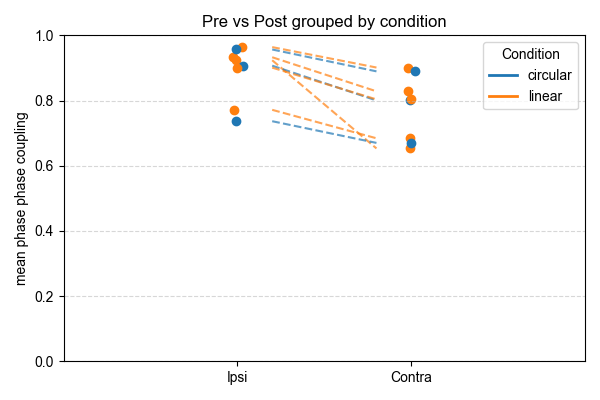

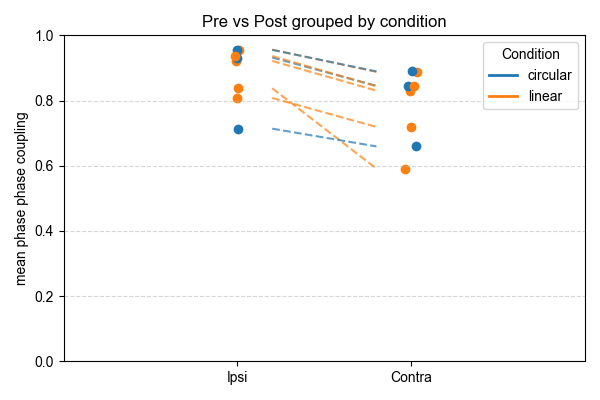

In [8]:
labels = np.array(['linear','linear','linear','linear','circular','circular','linear','circular'])

# Step 1: assign unique colors to each label
unique_labels = np.unique(labels)
cmap = plt.get_cmap('tab10')  # categorical colormap
color_map = {lab: cmap(i) for i, lab in enumerate(unique_labels)}

for state in [0,1]:
    r_value = mean_r_value[:,state,:].T.copy()
    # Step 2: plot
    plt.figure(figsize=(6, 4))
    x_coords = [0.2, 0.8]
    
    for i in range(r_value.shape[1]):
        lab = labels[i]
        color = color_map[lab]
        # Line between paired points
        plt.plot(x_coords, r_value[:, i], color=color, linestyle='--', alpha=0.7)
        # Plot dots
        jitter_strength = 0.02  # Adjust the strength of jitter
        x_values = np.random.randn(1) * jitter_strength
        plt.scatter(0+x_values, r_value[0, i], color=color, edgecolor=color)
        
        jitter_strength = 0.02  # Adjust the strength of jitter
        x_values = np.random.randn(1) * jitter_strength
        plt.scatter(1+x_values, r_value[1, i], color=color, edgecolor=color)
    
    # Step 3: legend for labels
    handles = [plt.Line2D([0], [0], color=color_map[lab], lw=2) for lab in unique_labels]
    plt.legend(handles, unique_labels, title='Condition', bbox_to_anchor=(1, 1))
    plt.grid(linestyle='--',alpha=0.5,axis='y')
    
    # Aesthetic touches
    plt.xticks([0, 1], ['Ipsi', 'Contra'])
    plt.xlim([-1, 2])
    plt.ylim([0, 1])
    plt.ylabel('mean phase phase coupling')
    plt.title('Pre vs Post grouped by condition')
    plt.tight_layout()
    
    os.chdir(scripts_path + '/figures/')
    fig_name = f'Figure_Ripple_AmpAmp_{state}_Average.svg'
    
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # helper.delete_clip_path(fig_name)



In [9]:
mean_r_value_df_long = (
    df.groupby(['session', 'state', 'side'], as_index=False)['r_value']
      .mean()
      .rename(columns={'r_value': 'mean_r_value'})
)

mean_r_value_df_long


,session,state,side,mean_r_value
0,Achilles_10252013,post,contra,0.888061
1,Achilles_10252013,post,ipsi,0.956319
2,Achilles_10252013,pre,contra,0.901456
3,Achilles_10252013,pre,ipsi,0.964093
4,Achilles_11012013,post,contra,0.889530
5,Achilles_11012013,post,ipsi,0.955592
6,Achilles_11012013,pre,contra,0.889698
7,Achilles_11012013,pre,ipsi,0.956807
8,Buddy_06272013,post,contra,0.591227
9,Buddy_06272013,post,ipsi,0.837756


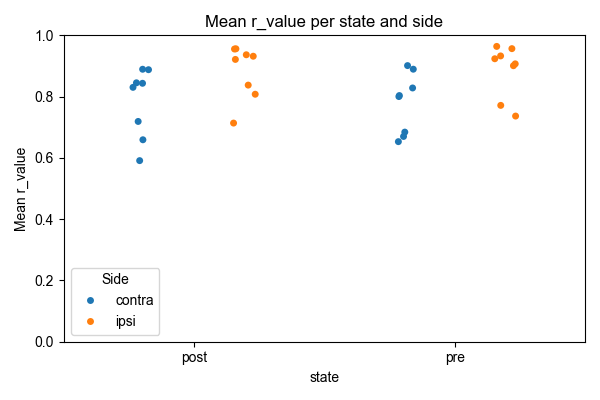

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have mean_r_value_df_long
plt.figure(figsize=(6, 4))
sns.stripplot(
    data=mean_r_value_df_long,
    x='state',
    y='mean_r_value',
    hue='side',
    dodge=True,
    jitter=True
)

plt.ylabel("Mean r_value")
plt.title("Mean r_value per state and side")
plt.legend(title="Side")
plt.ylim([0,1])
plt.tight_layout()
plt.show()


In [11]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "mean_r_value ~ C(side, Treatment(reference='ipsi')) * C(state, Treatment(reference='pre'))"
re_formula = "1"

# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, data=mean_r_value_df_long, groups='session')
result = model.fit()

# Print summary of the model
print(result.summary())


                                                Mixed Linear Model Regression Results
Model:                                      MixedLM                          Dependent Variable:                          mean_r_value
No. Observations:                           32                               Method:                                      REML        
No. Groups:                                 8                                Scale:                                       0.0019      
Min. group size:                            4                                Log-Likelihood:                              34.2067     
Max. group size:                            4                                Converged:                                   Yes         
Mean group size:                            4.0                                                                                       
--------------------------------------------------------------------------------------------------------

/home/apollo/.pyenv/versions/3.13.5/envs/ripple_sync/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [26]:
import numpy as np

# Define the contrast matrix for pairwise comparisons of 'side'
r_matrix = np.array([[0, 1, 0, 0],   # Test: 'ipsi' vs 'contra' at 'pre'
                     [0, 0, 1, 0],   # Test: 'ipsi' vs 'contra' at 'post'
                     [0, 0, 0, 1]])  # Test: Interaction effect

# Perform the t-test for the specified contrasts
contrast_results = result.t_test(r_matrix)

# Print the contrast results
print(contrast_results.summary())


                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.1079      0.022     -5.000      0.000      -0.150      -0.066
c1            -0.0040      0.022     -0.187      0.851      -0.046       0.038
c2             0.0085      0.031      0.278      0.781      -0.051       0.068


In [12]:
mean_r_value_df_long = (
    df.groupby(['session', 'state', 'side'], as_index=False)['r_value']
      .mean()
      .rename(columns={'r_value': 'mean_r_value'})
)

# Create a 'grp' column for combinations of 'side' and 'state'
mean_r_value_df_long['grp'] = mean_r_value_df_long['side'] + '_' + mean_r_value_df_long['state']

# Pivot the dataframe to have 'grp' as columns
df_pivot = mean_r_value_df_long.pivot(index='session', columns='grp', values='mean_r_value')
df_pivot


# Perform paired t-tests
p_values = {}
for col1 in df_pivot.columns:
    for col2 in df_pivot.columns:
        if col1 != col2 and (col2, col1) not in p_values:
            t_stat, p_val = stats.ttest_rel(df_pivot[col1], df_pivot[col2])
            p_values[(col1, col2)] = p_val

# Display p-values
p_values_df = pd.DataFrame(list(p_values.items()), columns=['Comparison', 'p-value'])
print(p_values_df)

from statsmodels.stats.multitest import multipletests

# Extract p-values from the previous step
pvals = p_values_df['p-value'].values

# Apply Benjamini-Hochberg correction
rejected, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')

# Add corrected p-values to the dataframe
p_values_df['p-value (corrected)'] = pvals_corrected
p_values_df['Reject H0'] = rejected

print(p_values_df)


                  Comparison   p-value
0  (contra_post, contra_pre)  0.734586
1   (contra_post, ipsi_post)  0.002477
2    (contra_post, ipsi_pre)  0.016921
3    (contra_pre, ipsi_post)  0.000481
4     (contra_pre, ipsi_pre)  0.002862
5      (ipsi_post, ipsi_pre)  0.783203
                  Comparison   p-value  p-value (corrected)  Reject H0
0  (contra_post, contra_pre)  0.734586             0.783203      False
1   (contra_post, ipsi_post)  0.002477             0.005724       True
2    (contra_post, ipsi_pre)  0.016921             0.025382       True
3    (contra_pre, ipsi_post)  0.000481             0.002887       True
4     (contra_pre, ipsi_pre)  0.002862             0.005724       True
5      (ipsi_post, ipsi_pre)  0.783203             0.783203      False
